In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [15]:
dataset=pd.read_csv("Students Social Media Addiction-ex-3.csv")
dataset.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [33]:
dataset.fillna(dataset.mean(numeric_only=True),inplace=True)

In [16]:
dataset=pd.get_dummies(dataset)

In [17]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [21]:
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

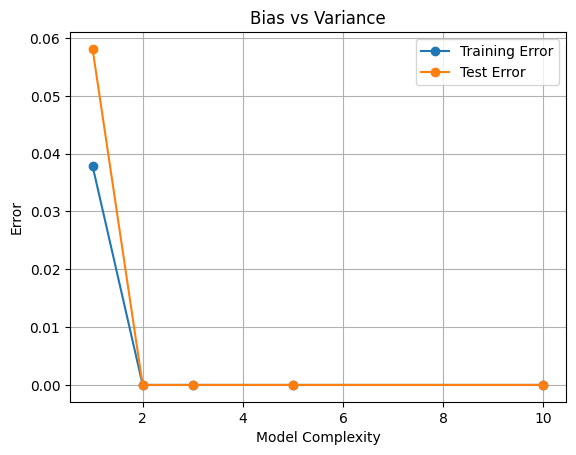

In [26]:
depth=[1,2,3,4,10]
train_error=[]
test_error=[]
for d in depth:
    model=DecisionTreeRegressor(max_depth=d)
    model.fit(X_train,y_train)
    train_error.append(mean_squared_error(y_train,model.predict(X_train)))
    test_error.append(mean_squared_error(y_test,model.predict(X_test)))                
plt.figure()
plt.plot(depths, train_errors, marker='o', label="Training Error")
plt.plot(depths, test_errors, marker='o', label="Test Error")
plt.title("Bias vs Variance")
plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()